# EDA Event-Driven Congestion (Planned & Unplanned)


In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")

In [34]:
cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents] if (p / "data").exists()), cwd)

DATASET_NAME = "Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv"
DATA_PATH = PROJECT_ROOT / "data" / DATASET_NAME

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

DATA_PATH

WindowsPath('D:/Python/Gridlock/Phase 2/theme 2/data/Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv')

## Load Data

In [35]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df.shape

(8173, 46)

In [36]:
df.head()

,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,start_datetime,end_datetime,status,authenticated,modified_datetime,map_file,direction,description,veh_type,veh_no,corridor,priority,cargo_material,reason_breakdown,age_of_truck,created_date,route_path,client_id,created_by_id,last_modified_by_id,assigned_to_police_id,citizen_accident_id,comment,police_station,meta_data,kgid,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,2024-03-07 17:01:48.111+00,NaN,closed,yes,2024-03-07 19:35:47.871698+00,NaN,NaN,s m circle in coming man track,lcv,FKN00GL0000,Tumkur Road,High,NaN,NaN,NaN,2024-03-07 17:03:51.164032+00,NaN,1,FKUSR00000,FKUSR00001,NaN,NaN,NaN,Peenya,NaN,FKKG000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,2024-01-30 04:07:24.173+00,NaN,resolved,yes,2024-01-30 04:17:46.828979+00,NaN,NaN,Starting problem,heavy_vehicle,FKN00GL0001,ORR East 1,High,NaN,NaN,NaN,2024-01-30 04:08:22.954979+00,NaN,1,FKUSR00002,FKUSR00001,NaN,NaN,NaN,HSR Layout,NaN,FKKG000001,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,2023-11-11 06:18:03.343+00,NaN,closed,yes,2024-01-30 04:56:03.282003+00,NaN,NaN,ಊರ್ವಶಿ ಜಂಕ್ಷನ್ ನಲ್ಲಿ ಒಳಚರಂಡಿ ಚೇಂಬರ್ ಗೆ ಹೊಸದಾಗಿ...,NaN,NaN,Non-corridor,Low,NaN,NaN,NaN,2023-11-11 06:20:00.989398+00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,2024-03-07 17:56:55.061+00,NaN,closed,yes,2024-03-14 07:42:05.55005+00,NaN,NaN,tree fall,NaN,NaN,Non-corridor,Low,NaN,NaN,NaN,2024-03-07 17:58:56.696892+00,NaN,1,FKUSR00004,FKUSR00001,NaN,NaN,NaN,Sadashivanagar,NaN,FKKG000003,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,2024-01-30 04:56:32.348+00,NaN,closed,yes,2024-01-30 05:35:17.33908+00,NaN,NaN,[LOCATION] ಪೈಪ್ [PERSON] ವಾಹನ ಆಫ್ ಆಗಿರುತ್ತದೆ ಸರ್,private_bus,FKN00GL0002,Non-corridor,Low,NaN,NaN,NaN,2024-01-30 04:58:55.937662+00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8173 non-null   str    
 1   event_type             8173 non-null   str    
 2   latitude               8173 non-null   float64
 3   longitude              8173 non-null   float64
 4   endlatitude            8004 non-null   float64
 5   endlongitude           8004 non-null   float64
 6   address                8170 non-null   str    
 7   end_address            687 non-null    str    
 8   event_cause            8173 non-null   str    
 9   requires_road_closure  8173 non-null   bool   
 10  start_datetime         8173 non-null   str    
 11  end_datetime           490 non-null    str    
 12  status                 8173 non-null   str    
 13  authenticated          8173 non-null   str    
 14  modified_datetime      8173 non-null   str    
 15  map_file       

## Basic Checks

In [38]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(dropna=True),
})

summary.sort_values("missing_pct", ascending=False)

,dtype,missing_pct,unique_values
comment,float64,100.00,0
map_file,float64,100.00,0
meta_data,float64,100.00,0
direction,str,99.47,8
resolved_at_address,str,99.09,58
resolved_at_latitude,float64,99.09,74
resolved_by_id,str,99.09,42
resolved_datetime,str,99.09,74
resolved_at_longitude,float64,99.09,74
assigned_to_police_id,str,98.43,62


In [39]:
pd.DataFrame({
    "total_rows": [len(df)],
    "duplicate_rows": [df.duplicated().sum()],
    "duplicate_ids": [df["id"].duplicated().sum() if "id" in df else np.nan],
})

,total_rows,duplicate_rows,duplicate_ids
0,8173,0,0


## Date Fields

In [40]:
date_cols = [
    "start_datetime",
    "end_datetime",
    "created_date",
    "modified_datetime",
    "closed_datetime",
    "resolved_datetime",
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

date_summary = []
for col in date_cols:
    date_summary.append({
        "column": col,
        "valid_rows": df[col].notna().sum(),
        "missing_rows": df[col].isna().sum(),
        "min": df[col].min(),
        "max": df[col].max(),
    })

pd.DataFrame(date_summary)

,column,valid_rows,missing_rows,min,max
0,start_datetime,8057,116,2023-11-09 19:24:48.154000+00:00,2024-04-08 17:11:42.780000+00:00
1,end_datetime,475,7698,2023-11-12 02:05:46+00:00,2027-11-09 11:35:46+00:00
2,created_date,8171,2,2023-09-29 23:38:19.342539+00:00,2024-04-08 17:22:58.849385+00:00
3,modified_datetime,8173,0,2023-11-09 20:35:47.789399+00:00,2024-04-20 06:16:08.264418+00:00
4,closed_datetime,3141,5032,2023-11-09 22:48:37.836256+00:00,2024-04-20 06:16:08.118135+00:00
5,resolved_datetime,74,8099,2023-11-10 07:21:41.463359+00:00,2024-04-02 22:33:50.469479+00:00


In [41]:
df["start_ist"] = df["start_datetime"].dt.tz_convert("Asia/Kolkata")
df["month"] = df["start_ist"].dt.strftime("%Y-%m")
df["hour"] = df["start_ist"].dt.hour
df["weekday"] = df["start_ist"].dt.day_name()
df["dayofweek"] = df["start_ist"].dt.dayofweek

df[["start_datetime", "start_ist", "month", "weekday", "hour"]].head()

,start_datetime,start_ist,month,weekday,hour
0,2024-03-07 17:01:48.111000+00:00,2024-03-07 22:31:48.111000+05:30,2024-03,Thursday,22.0
1,2024-01-30 04:07:24.173000+00:00,2024-01-30 09:37:24.173000+05:30,2024-01,Tuesday,9.0
2,2023-11-11 06:18:03.343000+00:00,2023-11-11 11:48:03.343000+05:30,2023-11,Saturday,11.0
3,2024-03-07 17:56:55.061000+00:00,2024-03-07 23:26:55.061000+05:30,2024-03,Thursday,23.0
4,2024-01-30 04:56:32.348000+00:00,2024-01-30 10:26:32.348000+05:30,2024-01,Tuesday,10.0


## Event Mix

In [42]:
key_cols = ["event_type", "event_cause", "requires_road_closure", "status", "priority", "corridor", "police_station", "veh_type"]

for col in key_cols:
    print(f"\n{col}")
    display(df[col].fillna("<missing>").value_counts().head(20).to_frame("records"))


event_type


,records
event_type,
unplanned,7706
planned,467



event_cause


,records
event_cause,
vehicle_breakdown,4896
others,638
pot_holes,537
construction,480
water_logging,458
accident,365
tree_fall,284
road_conditions,170
congestion,136



requires_road_closure


...

,records
corridor,
Non-corridor,3124
Mysore Road,743
Bellary Road 1,610
Tumkur Road,458
Bellary Road 2,379
Hosur Road,298
ORR North 1,275
Old Madras Road,263
Magadi Road,245



police_station


,records
police_station,
Yelahanka,377
HAL Old Airport,361
Sadashivanagar,302
Byatarayanapura,297
Halasuru Gate,297
Yeshwanthpura,280
Hennuru,276
Kodigehalli,272
Banaswadi,245



veh_type


,records
veh_type,
<missing>,3286
bmtc_bus,1466
heavy_vehicle,965
lcv,678
others,449
private_bus,359
private_car,345
truck,276
ksrtc_bus,217


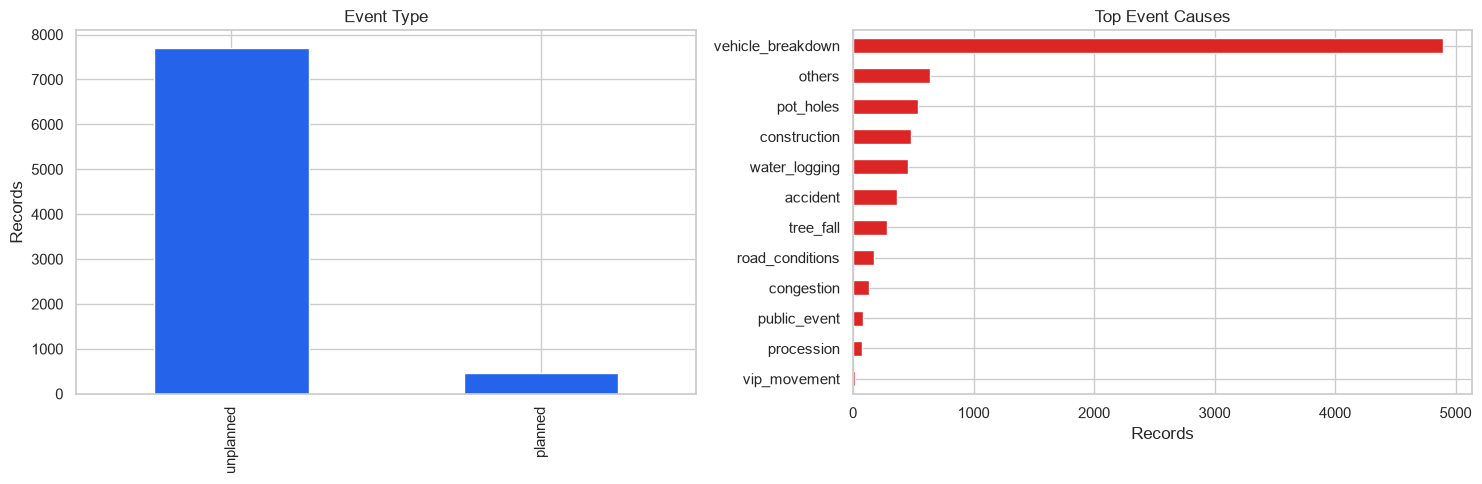

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df["event_type"].value_counts().plot(kind="bar", ax=axes[0], color="#2563EB")
axes[0].set_title("Event Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Records")

df["event_cause"].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[1], color="#DC2626")
axes[1].set_title("Top Event Causes")
axes[1].set_xlabel("Records")
axes[1].set_ylabel("")

plt.tight_layout()

## Road Closure Target

In [44]:
df["road_closure"] = df["requires_road_closure"].astype(str).str.lower().eq("true")
df["planned"] = df["event_type"].astype(str).str.lower().eq("planned")

pd.DataFrame({
    "records": [len(df)],
    "planned_events": [df["planned"].sum()],
    "road_closure_events": [df["road_closure"].sum()],
    "road_closure_rate_pct": [round(df["road_closure"].mean() * 100, 2)],
})

,records,planned_events,road_closure_events,road_closure_rate_pct
0,8173,467,676,8.27


In [45]:
closure_by_cause = (
    df.groupby("event_cause", dropna=False)
    .agg(records=("id", "size"), closures=("road_closure", "sum"))
    .assign(closure_rate_pct=lambda x: (x["closures"] / x["records"] * 100).round(2))
    .sort_values(["closures", "records"], ascending=False)
)

closure_by_cause

,records,closures,closure_rate_pct
event_cause,,,
vehicle_breakdown,4896,210,4.29
construction,480,127,26.46
tree_fall,284,112,39.44
others,638,55,8.62
water_logging,458,39,8.52
public_event,84,39,46.43
road_conditions,170,21,12.35
procession,72,19,26.39
vip_movement,20,16,80.00


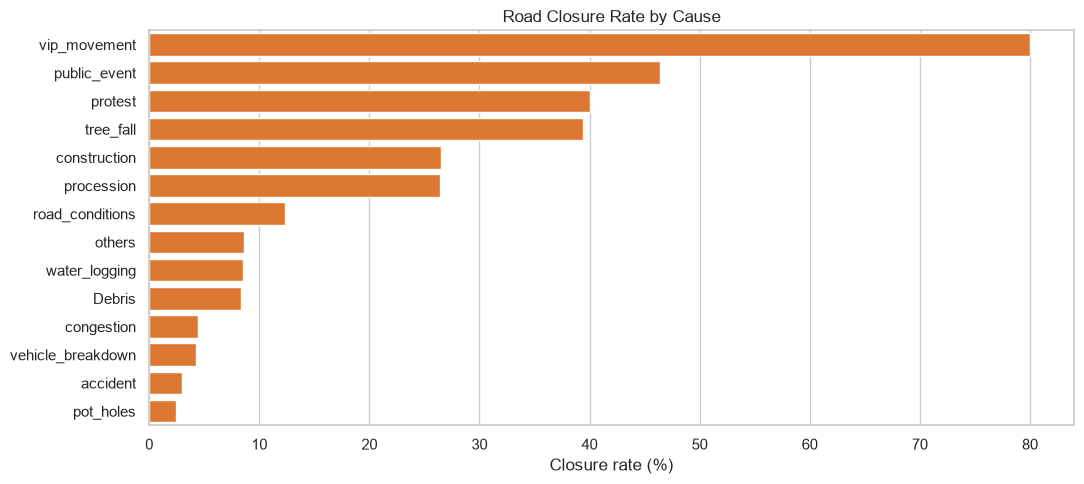

In [46]:
plot_data = closure_by_cause.query("records >= 10").sort_values("closure_rate_pct", ascending=False).head(15)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_data.reset_index(), x="closure_rate_pct", y="event_cause", color="#F97316")
plt.title("Road Closure Rate by Cause")
plt.xlabel("Closure rate (%)")
plt.ylabel("")
plt.tight_layout()

## Duration Checks

In [47]:
df["minutes_to_close"] = (df["closed_datetime"] - df["start_datetime"]).dt.total_seconds() / 60
df["minutes_to_resolve"] = (df["resolved_datetime"] - df["start_datetime"]).dt.total_seconds() / 60
df["minutes_to_modify"] = (df["modified_datetime"] - df["start_datetime"]).dt.total_seconds() / 60

duration_rows = []
for col in ["minutes_to_close", "minutes_to_resolve", "minutes_to_modify"]:
    s = df[col]
    plausible = s[s.between(0, 7 * 24 * 60)]
    duration_rows.append({
        "field": col,
        "valid_plausible": plausible.notna().sum(),
        "negative": (s < 0).sum(),
        "median_min": plausible.median(),
        "p90_min": plausible.quantile(0.90),
    })

pd.DataFrame(duration_rows).round(2)

,field,valid_plausible,negative,median_min,p90_min
0,minutes_to_close,2711,3,52.08,1343.12
1,minutes_to_resolve,72,0,59.00,118.89
2,minutes_to_modify,7606,2,123.11,207.74


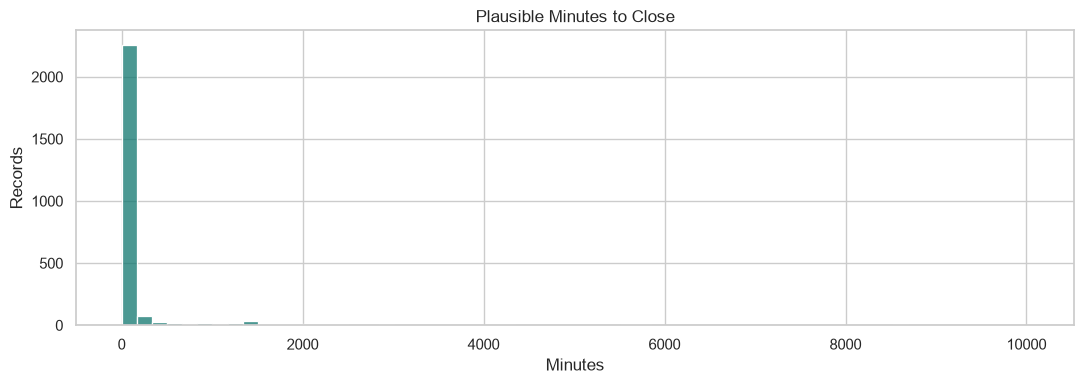

In [48]:
plausible_close = df.loc[df["minutes_to_close"].between(0, 7 * 24 * 60), "minutes_to_close"]

plt.figure(figsize=(11, 4))
sns.histplot(plausible_close, bins=60, color="#0F766E")
plt.title("Plausible Minutes to Close")
plt.xlabel("Minutes")
plt.ylabel("Records")
plt.tight_layout()

## Time Patterns

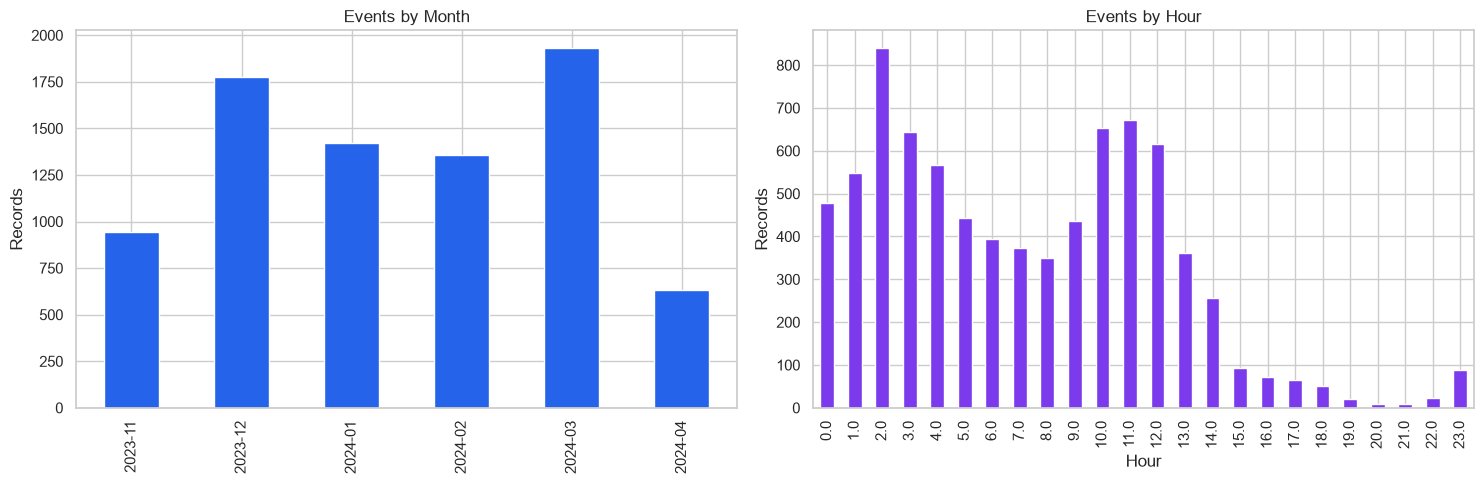

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df["month"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#2563EB")
axes[0].set_title("Events by Month")
axes[0].set_xlabel("")
axes[0].set_ylabel("Records")

df["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#7C3AED")
axes[1].set_title("Events by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Records")

plt.tight_layout()

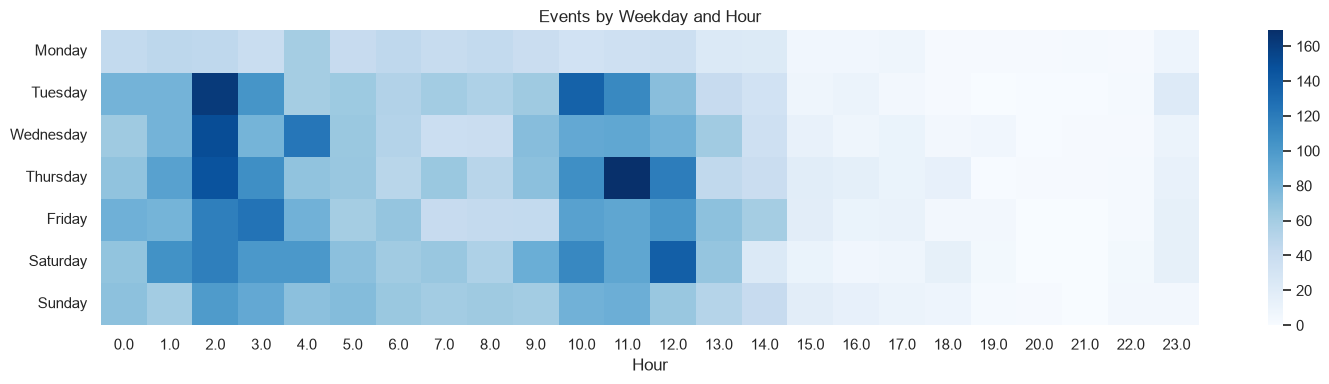

In [50]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_hour = pd.crosstab(df["weekday"], df["hour"]).reindex(weekday_order)

plt.figure(figsize=(15, 4))
sns.heatmap(weekday_hour, cmap="Blues")
plt.title("Events by Weekday and Hour")
plt.xlabel("Hour")
plt.ylabel("")
plt.tight_layout()

## Spatial Checks

In [51]:
pd.DataFrame({
    "metric": ["valid_coordinates", "lat_min", "lat_max", "lon_min", "lon_max"],
    "value": [
        df[["latitude", "longitude"]].notna().all(axis=1).sum(),
        df["latitude"].min(),
        df["latitude"].max(),
        df["longitude"].min(),
        df["longitude"].max(),
    ],
})

,metric,value
0,valid_coordinates,8173.000000
1,lat_min,12.801041
2,lat_max,13.267510
3,lon_min,77.308731
4,lon_max,77.769403


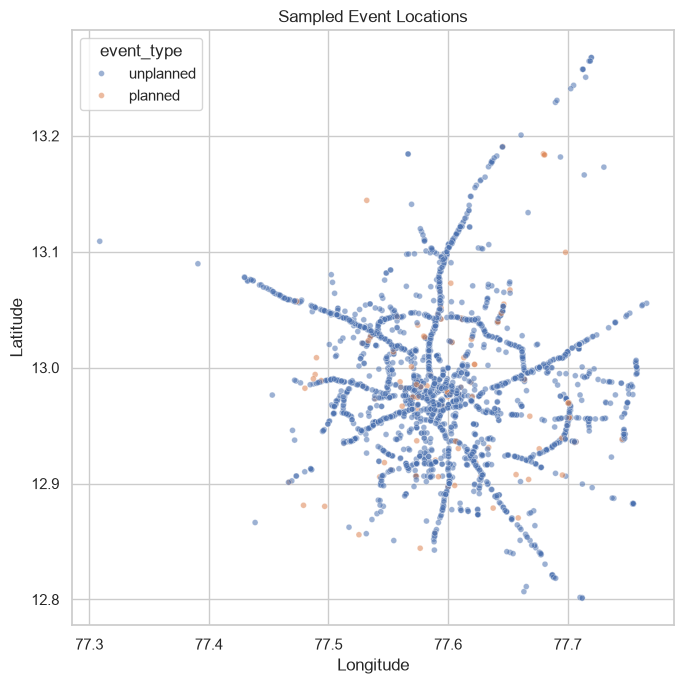

In [52]:
sample = df.sample(min(len(df), 3000), random_state=42)

plt.figure(figsize=(7, 7))
sns.scatterplot(data=sample, x="longitude", y="latitude", hue="event_type", s=18, alpha=0.55)
plt.title("Sampled Event Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

## Modelling Notes

In [53]:
forward_features = [
    "event_type", "latitude", "longitude", "event_cause", "start_datetime",
    "veh_type", "corridor", "police_station", "junction",
]

avoid_for_forward_prediction = [
    "status", "modified_datetime", "closed_datetime", "resolved_datetime",
    "closed_by_id", "resolved_by_id", "resolved_at_address",
    "resolved_at_latitude", "resolved_at_longitude", "last_modified_by_id",
]

pd.DataFrame({
    "use_candidate": pd.Series(forward_features),
    "avoid_leakage": pd.Series(avoid_for_forward_prediction),
})

,use_candidate,avoid_leakage
0,event_type,status
1,latitude,modified_datetime
2,longitude,closed_datetime
3,event_cause,resolved_datetime
4,start_datetime,closed_by_id
5,veh_type,resolved_by_id
6,corridor,resolved_at_address
7,police_station,resolved_at_latitude
8,junction,resolved_at_longitude
9,NaN,last_modified_by_id


## Leakage, Label Quality, and Operational Signals

This section reviews modelling-readiness checks: leakage risk, label reliability, reporting lag, multilingual text coverage, and repeat hotspot risk.

In [54]:
# Normalize exported null tokens before deeper diagnostics.
null_tokens = {"", "null", "none", "nan", "<na>", "na"}
text_like_cols = df.select_dtypes(include=["object", "string"]).columns

for col in text_like_cols:
    cleaned = df[col].astype("string").str.strip()
    df[col] = cleaned.where(~cleaned.str.lower().isin(null_tokens), pd.NA)

# Robust target parsing, even if the CSV is loaded as TRUE/FALSE strings elsewhere.
closure_raw = df["requires_road_closure"]
if pd.api.types.is_bool_dtype(closure_raw):
    df["road_closure"] = closure_raw.fillna(False).astype(bool)
else:
    df["road_closure"] = closure_raw.astype("string").str.strip().str.lower().isin({"true", "1", "yes", "y"})

for col in ["latitude", "longitude", "endlatitude", "endlongitude", "resolved_at_latitude", "resolved_at_longitude"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

pd.DataFrame({
    "records": [len(df)],
    "road_closure_events": [int(df["road_closure"].sum())],
    "road_closure_rate_pct": [round(df["road_closure"].mean() * 100, 2)],
    "planned_events": [int(df["event_type"].astype("string").str.lower().eq("planned").sum())],
})

,records,road_closure_events,road_closure_rate_pct,planned_events
0,8173,676,8.27,467


### Label Availability and Duration Reliability

The duration label should come only from outcome timestamps, and rows with implausible durations should be excluded from duration-band training.

In [55]:
duration_candidates = pd.DataFrame(index=df.index)
for col in ["end_datetime", "resolved_datetime", "closed_datetime"]:
    if col in df.columns:
        minutes = (df[col] - df["start_datetime"]).dt.total_seconds() / 60
        duration_candidates[col] = minutes.where(minutes.between(0, 24 * 60))

if not duration_candidates.empty:
    df["best_duration_minutes_24h"] = duration_candidates.min(axis=1)
    df["duration_band_24h"] = pd.cut(
        df["best_duration_minutes_24h"],
        bins=[0, 60, 240, 24 * 60],
        labels=["short_under_1h", "medium_1_4h", "long_4_24h"],
        include_lowest=True,
    )

label_quality = pd.DataFrame({
    "metric": [
        "closed_datetime_present",
        "resolved_datetime_present",
        "end_datetime_present",
        "valid_duration_0_24h",
        "road_closure_positive",
    ],
    "records": [
        int(df["closed_datetime"].notna().sum()),
        int(df["resolved_datetime"].notna().sum()),
        int(df["end_datetime"].notna().sum()),
        int(df.get("best_duration_minutes_24h", pd.Series(index=df.index, dtype=float)).notna().sum()),
        int(df["road_closure"].sum()),
    ],
})

label_quality["pct_of_dataset"] = (label_quality["records"] / len(df) * 100).round(2)
label_quality

,metric,records,pct_of_dataset
0,closed_datetime_present,3141,38.43
1,resolved_datetime_present,74,0.91
2,end_datetime_present,475,5.81
3,valid_duration_0_24h,2764,33.82
4,road_closure_positive,676,8.27


In [56]:
closure_timestamp_audit = pd.crosstab(
    df["road_closure"],
    df["closed_datetime"].notna(),
    rownames=["road_closure_target"],
    colnames=["closed_datetime_present"],
    margins=True,
)

closure_timestamp_audit

closed_datetime_present,False,True,All
road_closure_target,,,
False,4621,2876,7497
True,411,265,676
All,5032,3141,8173


### Reporting Lag and Temporal Risk

`report_lag_minutes` is calculated as `created_date - start_datetime`. This keeps the sign aligned with operational reporting delay.

In [57]:
df["report_lag_minutes"] = (df["created_date"] - df["start_datetime"]).dt.total_seconds() / 60
report_lag = df["report_lag_minutes"]

pd.DataFrame({
    "metric": ["negative_lag", "within_5_min", "within_30_min", "within_60_min", "over_24h"],
    "records": [
        int((report_lag < 0).sum()),
        int(report_lag.between(0, 5).sum()),
        int(report_lag.between(0, 30).sum()),
        int(report_lag.between(0, 60).sum()),
        int((report_lag > 24 * 60).sum()),
    ],
}).assign(pct_of_dataset=lambda x: (x["records"] / len(df) * 100).round(2))

,metric,records,pct_of_dataset
0,negative_lag,45,0.55
1,within_5_min,7453,91.19
2,within_30_min,7919,96.89
3,within_60_min,7937,97.11
4,over_24h,0,0.00


In [58]:
report_lag.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).to_frame("report_lag_minutes").round(2)

,report_lag_minutes
count,8057.00
mean,3.73
std,24.81
min,-1421.08
10%,0.70
25%,1.01
50%,1.53
75%,2.51
90%,4.10
95%,6.01


In [59]:
df["peak_period"] = np.select(
    [df["hour"].between(8, 11), df["hour"].between(17, 20), (df["hour"] >= 22) | (df["hour"] <= 5)],
    ["morning_peak", "evening_peak", "night"],
    default="off_peak",
)

time_risk = (
    df.groupby(["event_type", "peak_period"], dropna=False)["road_closure"]
    .agg(records="size", closures="sum", closure_rate="mean")
    .assign(closure_rate_pct=lambda x: (x["closure_rate"] * 100).round(2))
    .sort_values(["closure_rate", "records"], ascending=False)
)

time_risk

records  closures  closure_rate  closure_rate_pct
event_type peak_period                                                    
planned    off_peak          152        92      0.605263             60.53
           evening_peak       20        11      0.550000             55.00
           morning_peak       72        25      0.347222             34.72
           night             223        41      0.183857             18.39
unplanned  evening_peak      126        21      0.166667             16.67
           off_peak         2136       164      0.076779              7.68
           morning_peak     2037       123      0.060383              6.04
           night            3407       199      0.058409              5.84

### Hotspot and Cause Risk Tables

These summaries identify high-risk slices that can become historical aggregate features in the modelling notebook.

In [60]:
for col in ["event_type", "event_cause", "corridor", "police_station", "junction"]:
    if col in df.columns:
        risk = (
            df.groupby(col, dropna=False)["road_closure"]
            .agg(records="size", closures="sum", closure_rate="mean")
            .query("records >= 10")
            .assign(closure_rate_pct=lambda x: (x["closure_rate"] * 100).round(2))
            .sort_values(["closure_rate", "closures", "records"], ascending=False)
            .head(15)
        )
        print(f"\nTop closure-risk groups for {col}")
        display(risk[["records", "closures", "closure_rate_pct"]])


Top closure-risk groups for event_type


,records,closures,closure_rate_pct
event_type,,,
planned,467,169,36.19
unplanned,7706,507,6.58



Top closure-risk groups for event_cause


,records,closures,closure_rate_pct
event_cause,,,
vip_movement,20,16,80.00
public_event,84,39,46.43
protest,15,6,40.00
tree_fall,284,112,39.44
construction,480,127,26.46
procession,72,19,26.39
road_conditions,170,21,12.35
others,638,55,8.62
water_logging,458,39,8.52



Top closure-risk groups for corridor


,records,closures,closure_rate_pct
corridor,,,
Non-corridor,3124,378,12.10
Varthur Road,77,9,11.69
CBD 1,26,3,11.54
Mysore Road,743,82,11.04
Airport New South Road,67,7,10.45
ORR North 1,275,22,8.00
Old Airport Road,76,6,7.89
ORR East 1,244,18,7.38
CBD 2,104,7,6.73



Top closure-risk groups for police_station


,records,closures,closure_rate_pct
police_station,,,
Kengeri,44,16,36.36
K.G. Halli,74,20,27.03
City Market,27,6,22.22
Pulikeshinagar(F.Town),74,16,21.62
Basavanagudi,47,10,21.28
Wilson Garden,105,18,17.14
Sheshadripuram,123,19,15.45
Halasuru Gate,297,45,15.15
Upparpet,63,9,14.29



Top closure-risk groups for junction


,records,closures,closure_rate_pct
junction,,,
SadashivnagarJunc,13,5,38.46
Richmond circle jn,11,4,36.36
KrishnaFlourMill,19,6,31.58
Arbindo Circle,10,3,30.00
K R Circle,31,9,29.03
"VeerannapalyaJunction(BEL,HO)",30,7,23.33
SantheCircle,25,5,20.00
BMTCJunction-K H Road,10,2,20.00
HudsonCircle,16,3,18.75


In [61]:
closure_matrix = pd.crosstab(
    df["event_cause"],
    df["event_type"],
    values=df["road_closure"],
    aggfunc="mean",
).mul(100).round(2)

closure_matrix.loc[df["event_cause"].value_counts().head(15).index]

event_type,planned,unplanned
event_cause,,
vehicle_breakdown,33.33,4.27
others,0.00,8.63
pot_holes,NaN,2.42
construction,29.90,20.12
water_logging,NaN,8.52
accident,NaN,3.01
tree_fall,50.00,39.36
road_conditions,NaN,12.35
congestion,NaN,4.41


### Text and Language Coverage

Descriptions contain a substantial amount of non-English/Kannada text, so feature engineering should avoid English-only assumptions.

In [62]:
description = df["description"].fillna("").astype(str)
df["description_length"] = description.str.len()
df["description_word_count"] = description.str.split().str.len()
df["has_non_ascii_text"] = description.str.contains(r"[^\x00-\x7F]", regex=True).astype(int)
df["has_kannada_text"] = description.str.contains(r"[\u0C80-\u0CFF]", regex=True).astype(int)

pd.DataFrame({
    "metric": ["description_present", "non_ascii_description", "kannada_description", "median_description_length"],
    "value": [
        int(description.str.len().gt(0).sum()),
        int(df["has_non_ascii_text"].sum()),
        int(df["has_kannada_text"].sum()),
        round(float(df["description_length"].median()), 2),
    ],
})

,metric,value
0,description_present,6812.0
1,non_ascii_description,904.0
2,kannada_description,870.0
3,median_description_length,29.0


In [63]:
text_signal_risk = (
    df.groupby(["has_kannada_text", "has_non_ascii_text"])["road_closure"]
    .agg(records="size", closures="sum", closure_rate="mean")
    .assign(closure_rate_pct=lambda x: (x["closure_rate"] * 100).round(2))
)

text_signal_risk

records  closures  closure_rate  \
has_kannada_text has_non_ascii_text                                    
0                0                      7269       590      0.081167   
                 1                        34         5      0.147059   
1                1                       870        81      0.093103   

                                     closure_rate_pct  
has_kannada_text has_non_ascii_text                    
0                0                               8.12  
                 1                              14.71  
1                1                               9.31

### Coordinate Quality

Zero end coordinates usually mean no usable end point, not a true coordinate. Start coordinates should remain inside a broad Bengaluru bounding box for spatial modelling.

In [64]:
valid_start_coordinate = (
    df["latitude"].between(12.0, 14.2) &
    df["longitude"].between(76.5, 78.5)
)
end_coordinate_zero = (
    df[["endlatitude", "endlongitude"]].fillna(0).eq(0).any(axis=1)
    if {"endlatitude", "endlongitude"}.issubset(df.columns)
    else pd.Series(False, index=df.index)
)

coord_quality = pd.DataFrame({
    "metric": [
        "valid_start_coordinate_bbox",
        "missing_start_coordinate",
        "zero_or_missing_end_coordinate",
        "resolved_coordinate_present",
    ],
    "records": [
        int(valid_start_coordinate.sum()),
        int(df[["latitude", "longitude"]].isna().any(axis=1).sum()),
        int(end_coordinate_zero.sum()),
        int(df[["resolved_at_latitude", "resolved_at_longitude"]].notna().all(axis=1).sum()),
    ],
}).assign(pct_of_dataset=lambda x: (x["records"] / len(df) * 100).round(2))

coord_quality

,metric,records,pct_of_dataset
0,valid_start_coordinate_bbox,8173,100.00
1,missing_start_coordinate,0,0.00
2,zero_or_missing_end_coordinate,7484,91.57
3,resolved_coordinate_present,74,0.91


### EDA Takeaways

- The road-closure target is usable but imbalanced, so evaluation should focus on recall, precision-recall AUC, and tuned thresholds.
- Duration labels are available for a smaller subset and should be filtered to plausible 0-24 hour records before duration-band training.
- `created_date - start_datetime` is the correct operational report-lag direction.
- Planned events, cause, corridor, police station, junction, and peak period all provide useful risk slices.
- Descriptions are strongly multilingual, so feature engineering should preserve Kannada/non-ASCII indicators and leave room for multilingual embeddings later.
- End coordinates with zero values should be treated as missing with an explicit missing-endpoint flag.